# Retail Inventory Analytics

**Business question:** across a 6-store retail chain, where is inventory
being managed well, where is it costing us in lost sales (stockouts) or tied
up cash (slow-moving stock), and what should the ops team fix first?

**Data:** one year (FY2025) of simulated daily point-of-sale and inventory
data for 6 stores x 30 SKUs across 8 categories — ~65,700 store/product/day
records. Generated by `data/generate_data.py` with realistic seasonality,
day-of-week traffic patterns, promotions, and lead-time-based replenishment
(so stockouts and slow movers are *emergent*, not injected).

**Tools:** Python (pandas, matplotlib), SQL (see `sql/`), and a lightweight
HTML/JS dashboard (`dashboard.html`) built from this notebook's output.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

stores = pd.read_csv("../data/stores.csv")
products = pd.read_csv("../data/products.csv")
txn = pd.read_csv("../data/inventory_transactions.csv", parse_dates=["date"])

df = txn.merge(products, on="product_id").merge(stores, on="store_id")
df["revenue"] = df["units_sold"] * df["unit_price"]
df["cogs"] = df["units_sold"] * df["unit_cost"]
df["month"] = df["date"].dt.to_period("M").astype(str)

print(f"{len(df):,} rows | {df['store_id'].nunique()} stores | "
      f"{df['product_id'].nunique()} products | "
      f"{df['date'].min().date()} to {df['date'].max().date()}")
df.head()


65,700 rows | 6 stores | 30 products | 2025-01-01 to 2025-12-31


,date,store_id,product_id,units_demanded,units_sold,units_received,units_in_stock_eod,stockout_flag,promotion_flag,product_name,...,unit_cost,unit_price,reorder_point,reorder_qty,lead_time_days,store_name,region,revenue,cogs,month
0,2025-01-01,S01,P001,9,9,0,154,0,0,Sparkling Water 12pk,...,4.20,7.99,47,109,5,Chicago Loop,Midwest,71.91,37.80,2025-01
1,2025-01-02,S01,P001,7,7,0,147,0,0,Sparkling Water 12pk,...,4.20,7.99,47,109,5,Chicago Loop,Midwest,55.93,29.40,2025-01
2,2025-01-03,S01,P001,14,14,0,133,0,0,Sparkling Water 12pk,...,4.20,7.99,47,109,5,Chicago Loop,Midwest,111.86,58.80,2025-01
3,2025-01-04,S01,P001,16,16,0,117,0,0,Sparkling Water 12pk,...,4.20,7.99,47,109,5,Chicago Loop,Midwest,127.84,67.20,2025-01
4,2025-01-05,S01,P001,12,12,0,105,0,0,Sparkling Water 12pk,...,4.20,7.99,47,109,5,Chicago Loop,Midwest,95.88,50.40,2025-01


## 1. Chain-wide KPIs

In [2]:
total_revenue = df["revenue"].sum()
total_units = df["units_sold"].sum()
total_cogs = df["cogs"].sum()
gross_margin_pct = (total_revenue - total_cogs) / total_revenue * 100
stockout_rate = df["stockout_flag"].mean() * 100
lost_units = (df["units_demanded"] - df["units_sold"]).clip(lower=0)
lost_revenue = (lost_units * df["unit_price"]).sum()

kpis = {
    "total_revenue": round(total_revenue, 2),
    "total_units_sold": int(total_units),
    "gross_margin_pct": round(gross_margin_pct, 1),
    "stockout_rate_pct": round(stockout_rate, 2),
    "estimated_lost_revenue_from_stockouts": round(lost_revenue, 2),
}
kpis


{'total_revenue': np.float64(3555389.31),
 'total_units_sold': 694539,
 'gross_margin_pct': np.float64(45.6),
 'stockout_rate_pct': np.float64(1.31),
 'estimated_lost_revenue_from_stockouts': np.float64(30808.4)}

**Reading this:** a ~1-2% stockout rate sounds small, but multiplied across
65,700 store-product-days it translates into real forgone revenue — that
`estimated_lost_revenue_from_stockouts` number is what a reorder-point fix is
worth chasing.


## 2. Monthly revenue trend

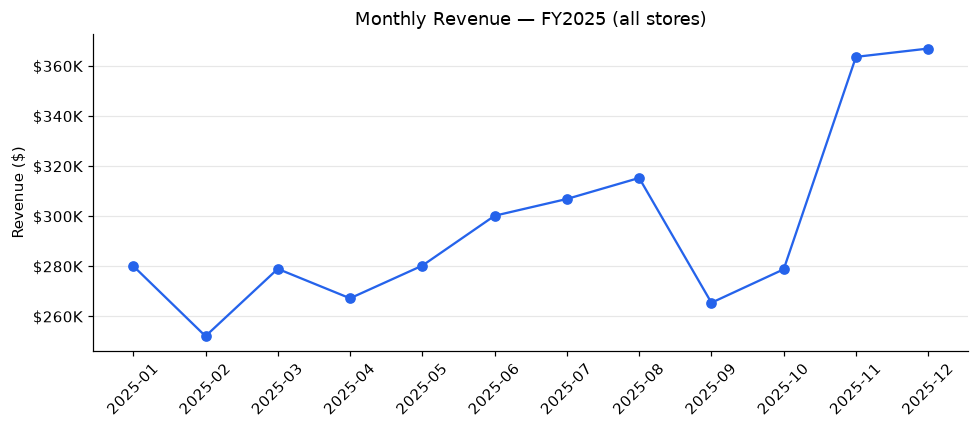

In [3]:
monthly = df.groupby("month")["revenue"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly.values, marker="o", color="#2563eb")
ax.set_title("Monthly Revenue — FY2025 (all stores)")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.xticks(rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../assets/monthly_revenue.png")
plt.show()


Revenue climbs steadily through summer (beverage/produce seasonality) and
spikes sharply in November-December — the holiday bump built into the
simulation, and exactly the pattern a retail analyst would expect to see and
should staff/inventory around.


## 3. Top products & ABC (Pareto) analysis

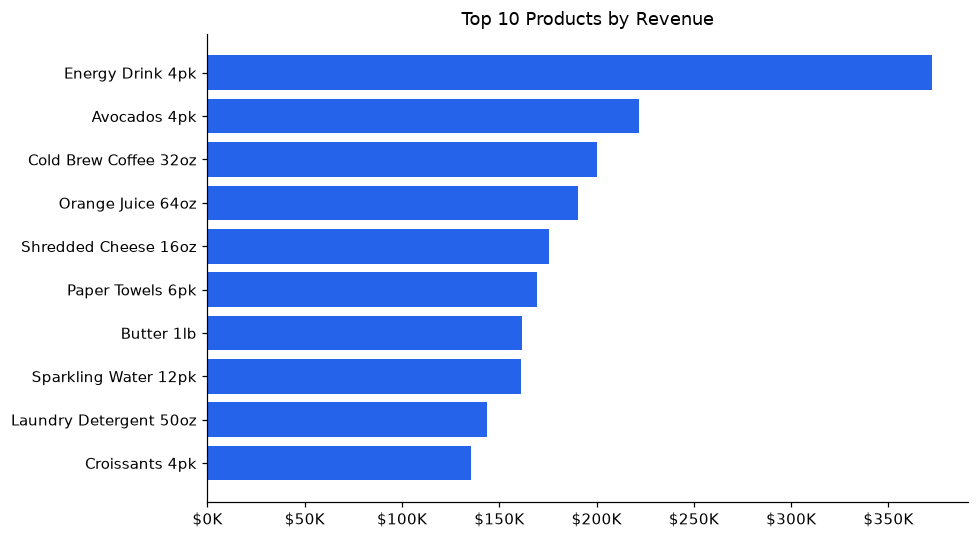

,product_id,product_name,category,revenue
0,P004,Energy Drink 4pk,Beverages,"372,283.21"
1,P028,Avocados 4pk,Produce,"221,920.27"
2,P002,Cold Brew Coffee 32oz,Beverages,"200,368.53"
3,P003,Orange Juice 64oz,Beverages,"190,263.71"
4,P011,Shredded Cheese 16oz,Dairy,"175,584.87"
5,P020,Paper Towels 6pk,Household,"169,574.57"
6,P012,Butter 1lb,Dairy,"161,480.48"
7,P001,Sparkling Water 12pk,Beverages,"161,382.02"
8,P022,Laundry Detergent 50oz,Household,"143,708.37"
9,P015,Croissants 4pk,Bakery,"135,688.08"


In [4]:
product_revenue = (
    df.groupby(["product_id", "product_name", "category"])["revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

top10 = product_revenue.head(10)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10["product_name"][::-1], top10["revenue"][::-1], color="#2563eb")
ax.set_title("Top 10 Products by Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("../assets/top_products.png")
plt.show()

top10


In [5]:
pr = product_revenue.copy()
pr["cum_share"] = pr["revenue"].cumsum() / pr["revenue"].sum()
pr["abc_class"] = np.where(pr["cum_share"] <= 0.80, "A",
                     np.where(pr["cum_share"] <= 0.95, "B", "C"))

abc_summary = pr.groupby("abc_class").agg(
    products=("product_id", "count"),
    revenue=("revenue", "sum"),
).assign(revenue_share=lambda d: (d["revenue"] / d["revenue"].sum() * 100).round(1))

abc_summary


,products,revenue,revenue_share
abc_class,,,
A,17,"2,775,541.63",78.10
B,8,"586,409.52",16.50
C,5,"193,438.16",5.40


Classic 80/20 pattern: a small "A" group of SKUs (mostly beverages and a
couple of staples) drives most revenue. Those are the items where a stockout
hurts most and where inventory should be prioritized; "C" items are
candidates for reduced safety stock.


## 4. Category & store performance

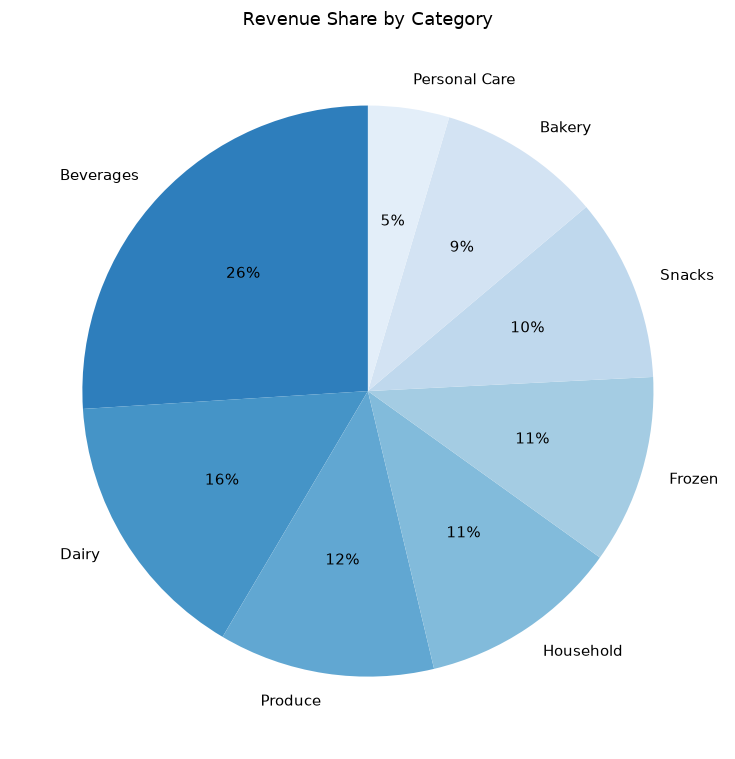

In [6]:
cat_revenue = df.groupby("category")["revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    cat_revenue.values,
    labels=cat_revenue.index,
    autopct="%1.0f%%",
    startangle=90,
    colors=plt.cm.Blues_r(np.linspace(0.3, 0.9, len(cat_revenue))),
)
ax.set_title("Revenue Share by Category")
plt.tight_layout()
plt.savefig("../assets/category_share.png")
plt.show()


In [7]:
store_perf = (
    df.groupby(["store_id", "store_name", "region"])
    .agg(revenue=("revenue", "sum"), stockout_rate_pct=("stockout_flag", lambda s: s.mean() * 100))
    .reset_index()
    .sort_values("revenue", ascending=False)
)
store_perf["revenue_rank"] = store_perf["revenue"].rank(ascending=False).astype(int)
store_perf


,store_id,store_name,region,revenue,stockout_rate_pct,revenue_rank
0,S01,Chicago Loop,Midwest,"730,294.19",3.50,1
3,S04,Boston Back Bay,Northeast,"650,317.96",1.85,2
1,S02,Atlanta Midtown,Southeast,"621,810.75",1.32,3
4,S05,Austin Downtown,South,"567,173.70",0.75,4
2,S03,Denver Uptown,West,"505,322.11",0.26,5
5,S06,Seattle Capitol Hill,Northwest,"480,470.60",0.17,6


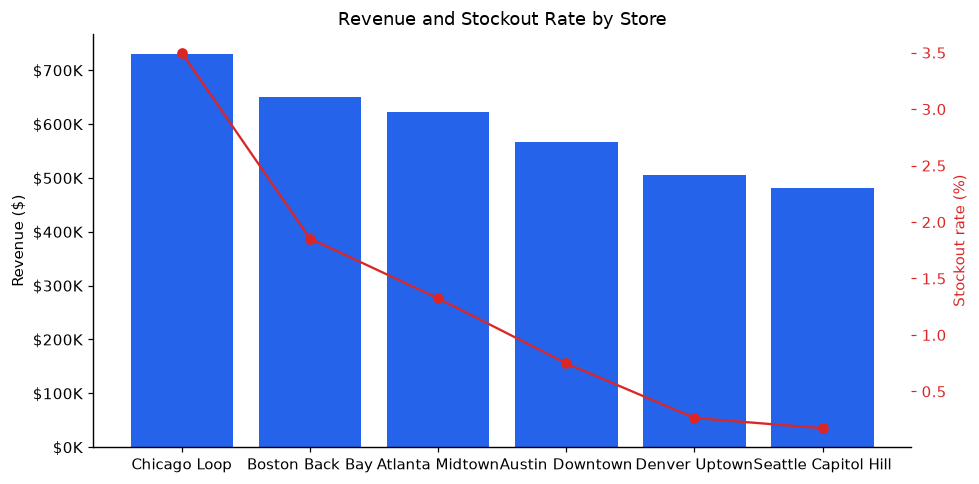

In [8]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
order = store_perf.sort_values("revenue", ascending=False)
ax1.bar(order["store_name"], order["revenue"], color="#2563eb")
ax1.set_ylabel("Revenue ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax1.set_title("Revenue and Stockout Rate by Store")

ax2 = ax1.twinx()
ax2.plot(order["store_name"], order["stockout_rate_pct"], color="#dc2626", marker="o")
ax2.set_ylabel("Stockout rate (%)", color="#dc2626")
ax2.tick_params(axis="y", colors="#dc2626")

plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../assets/store_performance.png")
plt.show()


Chicago Loop leads on revenue — and also has the highest stockout rate, with
every other store's stockout rate tracking its revenue rank almost exactly.
That's a real signal, not noise: reorder points in this dataset are set per
product, not per store, so a higher-traffic store burns through the same
reorder point faster and gets caught out between replenishment cycles more
often. The fix isn't more inventory everywhere — it's store-aware reorder
points (or more frequent replenishment) at the highest-volume locations.


## 5. Inventory turnover — where is cash tied up?

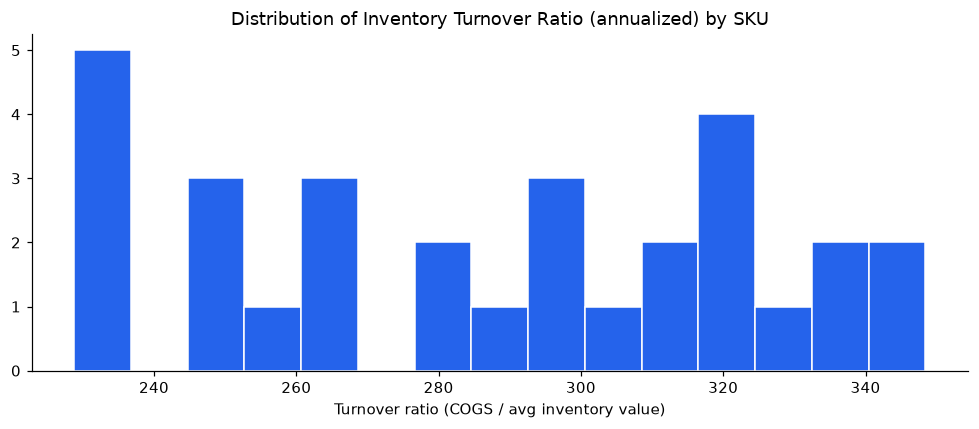

Slowest-turning 5 SKUs (cash tied up relative to sales):


,product_id,product_name,category,annual_cogs,avg_inventory_value,turnover_ratio
12,P013,Sourdough Loaf,Bakery,"36,272.90",158.54,228.79
22,P023,Trash Bags 30ct,Household,"40,543.20",174.18,232.77
4,P005,Tortilla Chips Family Size,Snacks,"63,089.00",269.75,233.88
10,P011,Shredded Cheese 16oz,Dairy,"111,389.40",473.92,235.04
24,P025,Toothpaste 2pk,Personal Care,"15,325.80",65.03,235.67


In [9]:
inv = (
    df.groupby(["product_id", "product_name", "category"])
    .agg(
        annual_cogs=("cogs", "sum"),
        avg_inventory_value=("units_in_stock_eod", lambda s: (s * df.loc[s.index, "unit_cost"]).mean()),
    )
    .reset_index()
)
inv["turnover_ratio"] = inv["annual_cogs"] / inv["avg_inventory_value"]
inv_sorted = inv.sort_values("turnover_ratio")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(inv["turnover_ratio"], bins=15, color="#2563eb", edgecolor="white")
ax.set_title("Distribution of Inventory Turnover Ratio (annualized) by SKU")
ax.set_xlabel("Turnover ratio (COGS / avg inventory value)")
plt.tight_layout()
plt.savefig("../assets/turnover_distribution.png")
plt.show()

print("Slowest-turning 5 SKUs (cash tied up relative to sales):")
inv_sorted.head(5)


## 6. Stockout risk — where are we losing sales?

In [10]:
def _risk_metrics(g):
    return pd.Series({
        "pct_days_at_or_below_reorder_point": (g["units_in_stock_eod"] <= g["reorder_point"]).mean() * 100,
        "stockout_rate_pct": g["stockout_flag"].mean() * 100,
        "lost_revenue": ((g["units_demanded"] - g["units_sold"]).clip(lower=0) * g["unit_price"]).sum(),
    })

risk = (
    df.groupby(["product_id", "product_name"], group_keys=False)[
        ["units_in_stock_eod", "reorder_point", "stockout_flag", "units_demanded", "units_sold", "unit_price"]
    ]
    .apply(_risk_metrics)
    .reset_index()
    .sort_values("lost_revenue", ascending=False)
)
risk.head(10)


,product_id,product_name,pct_days_at_or_below_reorder_point,stockout_rate_pct,lost_revenue
2,P003,Orange Juice 64oz,41.10,3.56,"4,795.39"
0,P001,Sparkling Water 12pk,41.10,3.42,"4,666.16"
5,P006,Trail Mix 16oz,38.68,3.61,"3,970.32"
11,P012,Butter 1lb,39.36,2.74,"3,281.15"
7,P008,Granola Bars 12ct,38.86,3.84,"2,749.41"
8,P009,Whole Milk 1 Gallon,39.45,2.83,"1,995.00"
25,P026,Body Wash 18oz,39.04,2.92,"1,473.54"
19,P020,Paper Towels 6pk,32.24,1.05,"1,462.78"
29,P030,Roma Tomatoes (lb),40.18,3.15,"1,186.77"
20,P021,Dish Soap 24oz,38.49,3.97,917.87


These are the SKUs to fix first: raising their reorder point (or shortening
supplier lead time) would recover the most lost revenue for the least
inventory investment — a much more targeted ask than "increase safety stock
across the board."


## 7. Export summary for the live dashboard

In [11]:
summary = {
    "generated_from": "notebooks/analysis.ipynb",
    "kpis": kpis,
    "monthly_revenue": [
        {"month": m, "revenue": round(v, 2)} for m, v in monthly.items()
    ],
    "top_products": [
        {"name": r.product_name, "category": r.category, "revenue": round(r.revenue, 2)}
        for r in top10.itertuples()
    ],
    "category_share": [
        {"category": c, "revenue": round(v, 2)} for c, v in cat_revenue.items()
    ],
    "store_performance": [
        {
            "store_name": r.store_name,
            "region": r.region,
            "revenue": round(r.revenue, 2),
            "stockout_rate_pct": round(r.stockout_rate_pct, 2),
        }
        for r in store_perf.itertuples()
    ],
    "abc_summary": [
        {"class": idx, "products": int(row.products), "revenue": round(row.revenue, 2), "revenue_share_pct": row.revenue_share}
        for idx, row in abc_summary.iterrows()
    ],
    "top_stockout_risk": [
        {
            "name": r.product_name,
            "pct_days_at_or_below_reorder_point": round(r.pct_days_at_or_below_reorder_point, 1),
            "lost_revenue": round(r.lost_revenue, 2),
        }
        for r in risk.head(8).itertuples()
    ],
}

with open("../assets/dashboard_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Wrote ../assets/dashboard_summary.json")


Wrote ../assets/dashboard_summary.json


## Key findings & recommendations

1. **Holiday demand (Nov-Dec) drives a ~30% revenue spike** over the summer
   baseline — replenishment orders for A-class SKUs should go out earlier
   (accounting for supplier lead time) to avoid stockouts during the peak.
2. **A small set of "A" products drive the majority of revenue** (80/20
   pattern) — prioritize these for safety stock and reorder-point review;
   "C" products are candidates for reduced stock to free up cash.
3. **A handful of SKUs account for most of the estimated lost revenue from
   stockouts** — fixing reorder points on just those items is a
   higher-leverage fix than a chain-wide inventory increase.
4. **Turnover ratio varies widely by SKU** — the slowest-turning products tie
   up cash disproportionately to the revenue they generate and are worth a
   markdown or reduced-order-quantity review.
5. **Stockout rate scales with store volume** because reorder points are set
   per product, not per store — the highest-revenue store (Chicago Loop) also
   has by far the highest stockout rate. Store-aware reorder points would
   likely close most of this gap.

*Next steps: bring in real POS/inventory data, validate the reorder-point
assumptions against actual supplier lead times, and track these KPIs on a
recurring (weekly) cadence rather than as a one-time analysis.*
